# Chebyshev approximation of the inverse function

In this notebook we present three ways of approximating the inverse function with Chebyshev polynomials, **given the polynomial degree**:

1. **Optimized relative error** (`optimized_rel`): the polynomial $p(x)$ minimising
$$\max_{x\in[1/\kappa,\,1]}|x\,p(x)-1|.$$

2. **Optimized uniform error** (`optimized_uni`): the polynomial $p(x)$ minimising
$$\max_{x\in[1/\kappa,\,1]}|p(x)-1/x|.$$

3. **CKS trimmed** (`cks_trimmed`): polynomial approximation of the inverse function from the original CKS paper [[1]](#references), trimmed to the target degree.

$$
\Large
P(y) = \sum^{(d-1)/2}_{j=0} (-1)^j a_j T_{2j+1}(y)
$$


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from banded_be import *
from cheb_utils import fit_linear_coeffs_for_cheb, get_numpy_cheb_trimmed
from numpy.polynomial.chebyshev import Chebyshev
from scipy import sparse
from scipy.special import eval_chebyt

from classiq.applications.chemistry.op_utils import qubit_op_to_qmod
from classiq.applications.qsp.qsp import poly_inversion

In [2]:
import pathlib

path = (
    pathlib.Path(__file__).parent.resolve()
    if "__file__" in locals()
    else pathlib.Path(".")
)

In [3]:
def eval_odd_cheb_poly(coef, x):
    # coef[k] * T_{2k+1}(x)
    return sum(coef[k] * eval_chebyt(2 * k + 1, x) for k in range(len(coef)))


ALLOWED_CHEB_APPROX = ["optimized_rel", "optimized_uni", "cks_trimmed"]


def get_cheb_coeff(w_min, degree, scale=1, method="optimized_rel", epsilon=1e-4):
    assert (
        method in ALLOWED_CHEB_APPROX
    ), f"method must be one of {ALLOWED_CHEB_APPROX}, got {method!r}"

    kappa = 1 / w_min
    B = int(kappa**2 * np.log(kappa / epsilon))
    j0 = int(np.sqrt(B * np.log(4 * B / epsilon)))
    theoretical_degree = 2 * j0 + 1
    print(
        f"kappa={kappa:.2f}, theoretical degree for epsilon={epsilon}: {theoretical_degree}"
    )

    if method == "optimized_rel":
        print(f"  -> optimized relative-error polynomial, degree {degree}")
        c, m = poly_inversion(degree, kappa, "relative")
        return scale * c / m, scale / m

    if method == "optimized_uni":
        print(f"  -> optimized uniform-error polynomial, degree {degree}")
        c, m = poly_inversion(degree, kappa, "uniform")
        return scale * c / m, scale / m

    if method == "cks_trimmed":
        print(
            f"  -> CKS degree-{theoretical_degree} polynomial trimmed to degree {degree}"
        )
        return (
            get_numpy_cheb_trimmed(w_min, B, scale, degree, theoretical_degree),
            scale * w_min,
        )

We upload some matrix, and considered its block-encoding. We need the block-encoding scaling factor in order to calculate the effective range of singular/eigen-values.

In [4]:
mat_name = "nozzle_008_mat"
matfile = "matrices/" + mat_name + ".npz"
mat_raw_scr = sparse.load_npz(path / matfile)
data_size, block_size, be_scaling_factor, be_qfunc = get_banded_diags_be(mat_raw_scr)

In [5]:
mat_raw = mat_raw_scr.toarray()

In [6]:
svd = np.linalg.svd(mat_raw / be_scaling_factor)[1]
w_min = min(svd)
w_max = max(svd)
scale = 0.5

print(f"min singular value: {w_min:.4f}, max singular value: {w_max:.4f}")

params = [
    {"degree": 127, "method": "optimized_rel"},
    {"degree": 255, "method": "optimized_rel"},
    {"degree": 255, "method": "optimized_uni"},
    {"degree": 255, "method": "cks_trimmed"},
]

min singular value: 0.0133, max singular value: 0.5218


kappa=74.93, theoretical degree for epsilon=0.0001: 2575
  -> optimized relative-error polynomial, degree 127
kappa=74.93, theoretical degree for epsilon=0.0001: 2575
  -> optimized relative-error polynomial, degree 255
kappa=74.93, theoretical degree for epsilon=0.0001: 2575
  -> optimized uniform-error polynomial, degree 255
kappa=74.93, theoretical degree for epsilon=0.0001: 2575
  -> CKS degree-2575 polynomial trimmed to degree 255


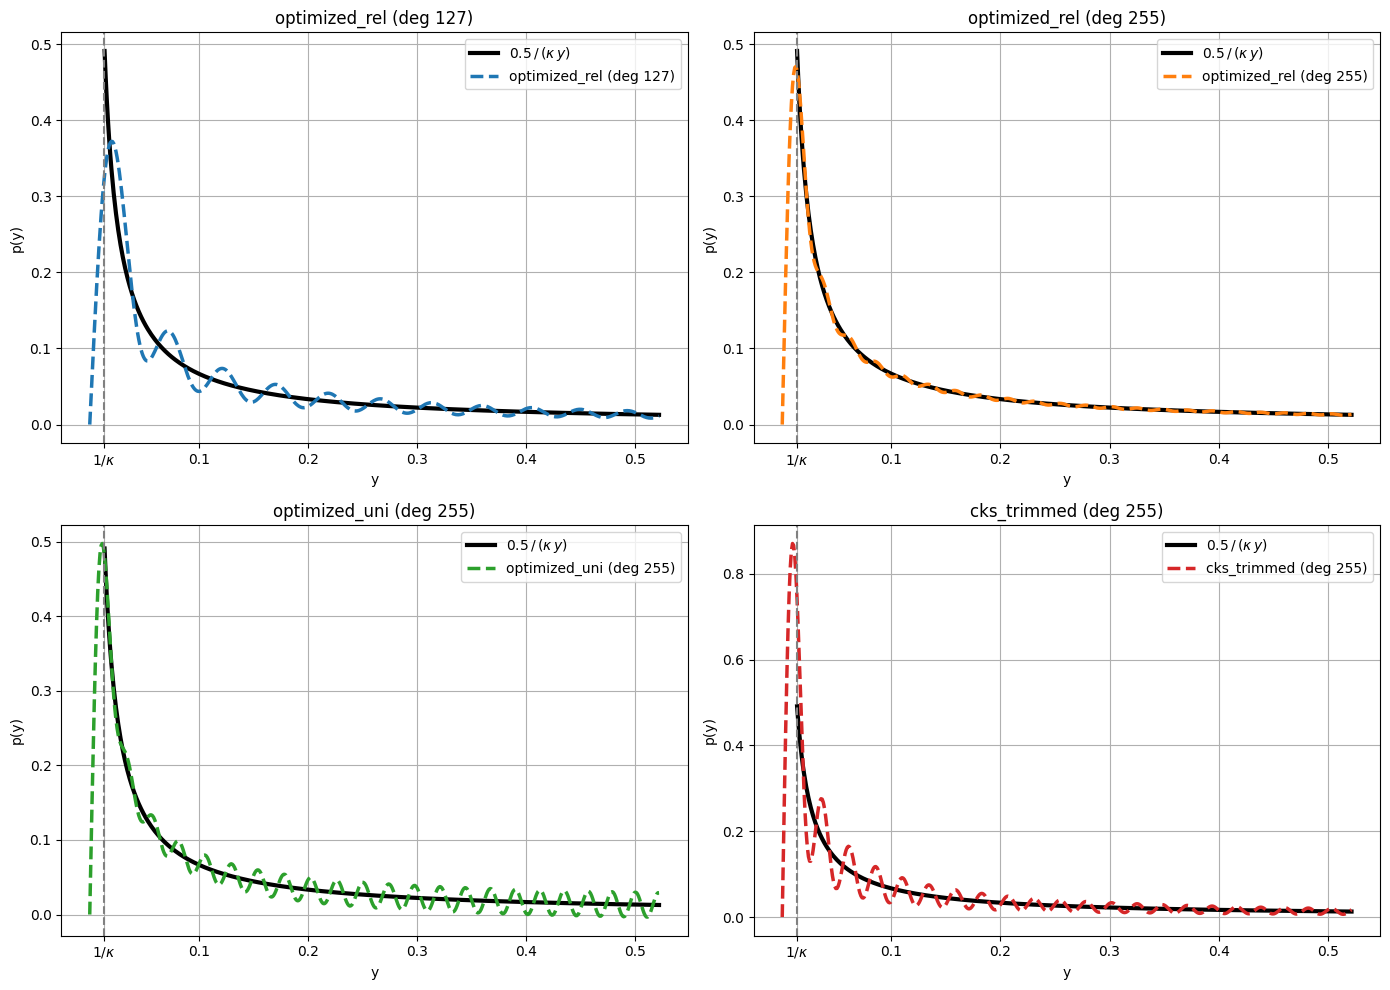

In [7]:
kappa = 1 / w_min
x_vals = np.linspace(0, w_max, 500)
mask = (np.abs(x_vals) >= w_min) & (np.abs(x_vals) <= w_max)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, p in enumerate(params):
    ax = axes_flat[i]
    coeffs, norm = get_cheb_coeff(w_min, p["degree"], scale=scale, method=p["method"])
    odd_coeffs = coeffs[1::2]
    approx = (scale * w_min / norm) * eval_odd_cheb_poly(odd_coeffs, x_vals)

    ax.plot(
        x_vals[mask],
        scale * w_min / x_vals[mask],
        "-k",
        label=r"$0.5\,/\,(\kappa\, y)$",
        linewidth=3,
    )
    ax.plot(
        x_vals,
        approx,
        "--",
        color=colors[i % len(colors)],
        label=f'{p["method"]} (deg {p["degree"]})',
        linewidth=2.5,
    )
    ax.axvline(x=w_min, color="gray", linestyle="--", linewidth=1.5)

    auto_ticks = [t for t in ax.get_xticks() if 0 < t < w_max and abs(t - w_min) > 1e-6]
    all_ticks = sorted(auto_ticks + [w_min])
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(
        [r"$1/\kappa$" if abs(t - w_min) < 1e-6 else f"{t:.2g}" for t in all_ticks]
    )

    ax.set_xlabel("y")
    ax.set_ylabel("p(y)")
    ax.set_title(f'{p["method"]} (deg {p["degree"]})')
    ax.legend()
    ax.grid(True)

for j in range(len(params), 4):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
degree = 255
sp_error = 0.03

coeffs, norm = get_cheb_coeff(w_min, degree, scale=scale, method="optimized_rel")

fitted_cheb_coeffs = fit_linear_coeffs_for_cheb(coeffs)
odd_coef = fitted_cheb_coeffs

positive_ind = np.arange(len(odd_coef))[0::2]
positive_fitted = odd_coef[0::2]
negative_ind = np.arange(len(odd_coef))[1::2]
negative_fitted = odd_coef[1::2]
# Calculate prep for Chebyshev LCU
lcu_size_inv = len(odd_coef).bit_length() - 1
odd_coeffs_signs = np.sign(odd_coef)
assert np.all(
    odd_coeffs_signs == np.where(np.arange(len(odd_coeffs_signs)) % 2 == 0, 1, -1)
), "Non alternating signs for odd coefficients"
normalization_inv = sum(np.abs(odd_coef))
prepare_probs_inv = (np.abs(odd_coef) / normalization_inv).tolist()

simulated_amps = []
number_of_ry = []
qprogs = []
for index, err in enumerate([0.0, sp_error]):

    @qfunc
    def main(inv_block: Output[QNum[lcu_size_inv]]):
        allocate(inv_block)
        inplace_prepare_state(prepare_probs_inv, err, inv_block)

    qprog = synthesize(
        main,
        preferences=Preferences(
            custom_hardware_settings=CustomHardwareSettings(
                basis_gates=["cx", "ry", "h", "x", "y", "z", "s", "t"]
            )
        ),
    )

    qprogs.append(qprog)
    print(f"for {err}: {qprog.transpiled_circuit.count_ops}")
    number_of_ry.append(qprog.transpiled_circuit.count_ops["ry"])

    df = calculate_state_vector(qprog)
    abs_simulated_amps = np.zeros(2**lcu_size_inv)
    abs_simulated_amps[df["inv_block"]] = df["probability"]
    simulated_amps.append(
        [
            (-1) ** k * abs_simulated_amps[k] * normalization_inv
            for k in range(2**lcu_size_inv)
        ]
    )

kappa=74.93, theoretical degree for epsilon=0.0001: 2575
  -> optimized relative-error polynomial, degree 255
linear fit parameters: slope = -0.00010397734302726348, b= 0.014094618961514992


Submitting job to simulator


for 0.0: {'s': 516, 'h': 264, 'z': 258, 'ry': 127, 'cx': 126}


Job: https://platform.classiq.io/jobs/df339f85-c41d-45c8-8f36-035a22c2761f
Submitting job to simulator


for 0.03: {'s': 28, 'h': 16, 'z': 14, 'ry': 11, 'cx': 6}


Job: https://platform.classiq.io/jobs/36086102-5419-4212-b400-c60036cf6c01


In [9]:
assert number_of_ry[1] < number_of_ry[0] / 2

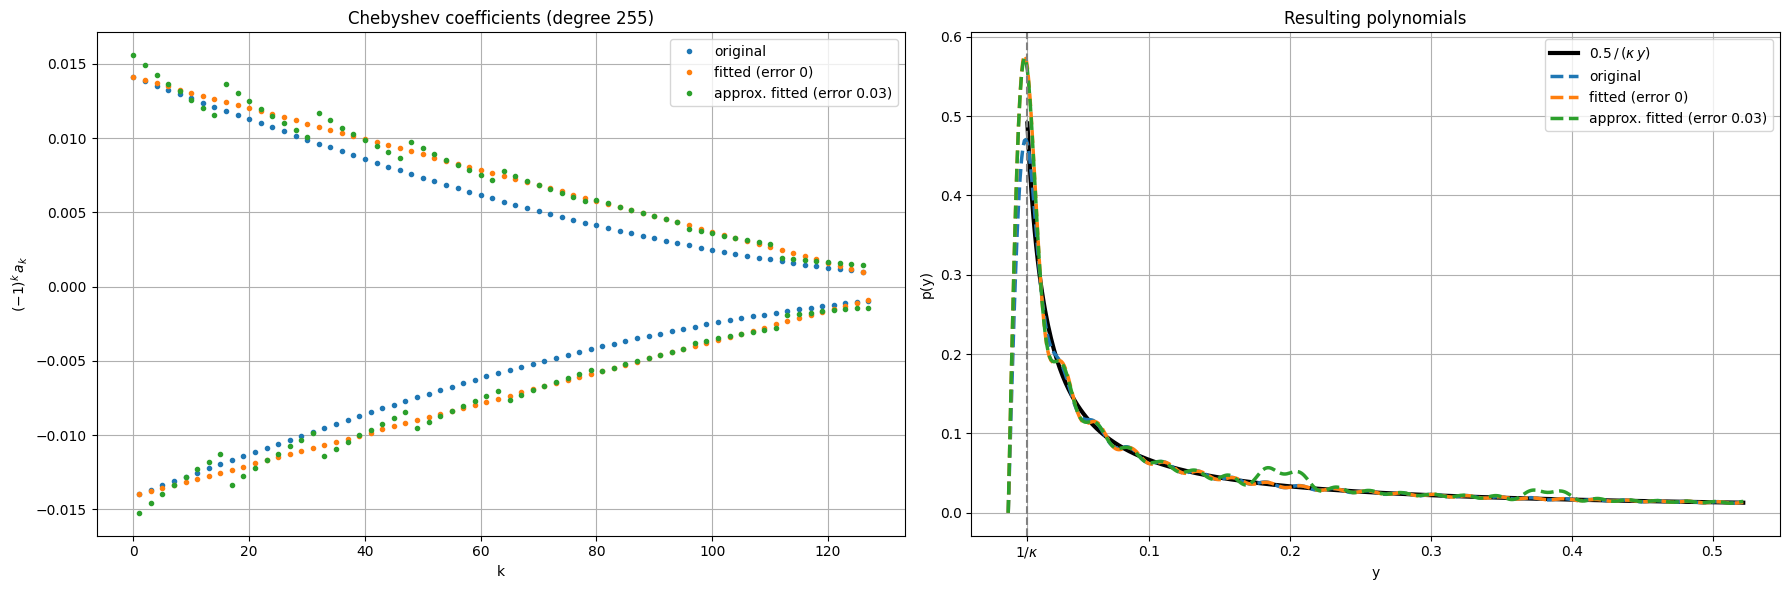

In [10]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(18, 6))

# Plot coefficients
ax_a.plot(coeffs[1::2], ".", markersize=6, label="original")
ax_a.plot(simulated_amps[0], ".", markersize=6, label="fitted (error 0)")
ax_a.plot(
    simulated_amps[1], ".", markersize=6, label=f"approx. fitted (error {sp_error})"
)
ax_a.set_xlabel("k")
ax_a.set_ylabel(r"$(-1)^k\,a_k$")
ax_a.set_title(f"Chebyshev coefficients (degree {degree})")
ax_a.legend()
ax_a.grid(True)

# Plot the resulting polynomial
fac = scale * w_min / norm
poly_orig = fac * eval_odd_cheb_poly(coeffs[1::2], x_vals)
poly_fit = fac * eval_odd_cheb_poly(simulated_amps[0], x_vals)
poly_approx = fac * eval_odd_cheb_poly(simulated_amps[1], x_vals)

ax_b.plot(
    x_vals[mask],
    scale * w_min / x_vals[mask],
    "-k",
    label=r"$0.5\,/\,(\kappa\,y)$",
    linewidth=3,
)
ax_b.plot(x_vals, poly_orig, "--", linewidth=2.5, label="original")
ax_b.plot(x_vals, poly_fit, "--", linewidth=2.5, label="fitted (error 0)")
ax_b.plot(
    x_vals, poly_approx, "--", linewidth=2.5, label=f"approx. fitted (error {sp_error})"
)
ax_b.axvline(x=w_min, color="gray", linestyle="--", linewidth=1.5)

auto_ticks = [t for t in ax_b.get_xticks() if 0 < t < w_max and abs(t - w_min) > 1e-6]
all_ticks = sorted(auto_ticks + [w_min])
ax_b.set_xticks(all_ticks)
ax_b.set_xticklabels(
    [r"$1/\kappa$" if abs(t - w_min) < 1e-6 else f"{t:.2g}" for t in all_ticks]
)
ax_b.set_xlabel("y")
ax_b.set_ylabel("p(y)")
ax_b.set_title("Resulting polynomials")
ax_b.legend()
ax_b.grid(True)

plt.tight_layout()
plt.show()

## References <a name="references"></a>

[1] Andrew M. Childs, Robin Kothari, and Rolando D. Somma. *Quantum algorithm for systems of linear equations with exponentially improved dependence on precision.* SIAM Journal on Computing, 46:1920, 2017.